In [1]:
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'
# os.environ['CUDA_VISIBLE_DEVICES'] = '2'
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

In [1]:
import jax
import pickle
import numpy as np
import matplotlib.pyplot as plt
from aim_resolve import OptimizeKLConfig, SetupKLConfig, SignalGrid, get_builders, plot_arrays, map_signal

jax.config.update("jax_enable_x64", True)

jwst not installed. Some JWST functions will not work.
shapely not installed. Some JWST functions will not work.


/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
def box_markers(cfg, ps_map, grid, it):
    import numpy as np
    from aim_resolve import draw_boxes

    px, py = np.argwhere(ps_map > 0).T
    ps_mrk = dict(x=px, y=py, marker='+', c='#EE220C', lw=0.25, s=5)
    # ps_mrk = dict(x=px, y=py, marker='+', c='black', lw=0.25, s=5)
    # ps_mrk = dict(x=px, y=py, s=10, facecolors='none', edgecolors='#EE220C')
    box_map = draw_boxes(cfg.sections, grid, it)
    ox, oy = np.argwhere(box_map > 0).T
    oj_mrk = dict(x=ox, y=oy, marker='o', c='#3275B5', lw=0, s=(72/300)**2)
    
    return dict(ps_mrk=ps_mrk, oj_mrk=oj_mrk)

In [8]:
dir = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_1f_1024_1z_b'

mf_rec = '3_rec_2z_4f'
mf_it = 5

ARCMIN2RAD = np.pi / 60 / 180
AS2RAD = ARCMIN2RAD / 60
CONV_FACTOR = 1000 * AS2RAD**2


opt_yml = f'{dir}/opt/{mf_rec}/opt.yml'
print('load:', opt_yml)

optim_cfg = OptimizeKLConfig.from_file(opt_yml, get_builders, 'major')
optim_cfg.sections['data.0']['fname'] = '/Users/rf/Development/data/eso_986-1137mhz.npz'

sky_mf = optim_cfg.instantiate_sec(f'sky.{mf_it}')
print('sky components:', [c.prefix for c in sky_mf.models])

with open(f'{dir}/opt/{mf_rec}/last.pkl', "rb") as f:
    samples_mf, *_ = pickle.load(f)
print('samples:', len(samples_mf))

setup_cfg = SetupKLConfig.from_file(opt_yml)
sky_ps = sky_mf.points[0]
ps_map = map_signal(sky_ps.points.grid, sky_ps.grid)(np.ones(sky_ps.shape)).sum(axis=0)
markers_mf = box_markers(setup_cfg, ps_map, sky_mf.grid, mf_it)
print('markers:', [f'{k}: {len(v["x"])}' for k, v in markers_mf.items()])

load: /Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_1f_1024_1z_b/opt/3_rec_2z_4f/opt.yml
sky components: ['bg.5', 'p0.5', 'o0.5', 'o1.5', 'o2.5', 't0.5']
samples: 4
markers: ['ps_mrk: 156', 'oj_mrk: 35550']


In [12]:
min_mf = 2.5e-3
max_mf = np.max(samples_mf.mean(sky_mf.ref_freq_model) * CONV_FACTOR)
print('vmin:', min_mf, '\nvmax:', max_mf)

plot_dict = dict(
    name = None,
    odir = None,
    norm = 'log',
    vmin = min_mf,
    vmax = max_mf,
    cmap = 'Blues',
    cbar = False,
    ticks = 0,
    dpi=300,
)

vmin: 0.0025 
vmax: 5.070727680217303


plotting ...


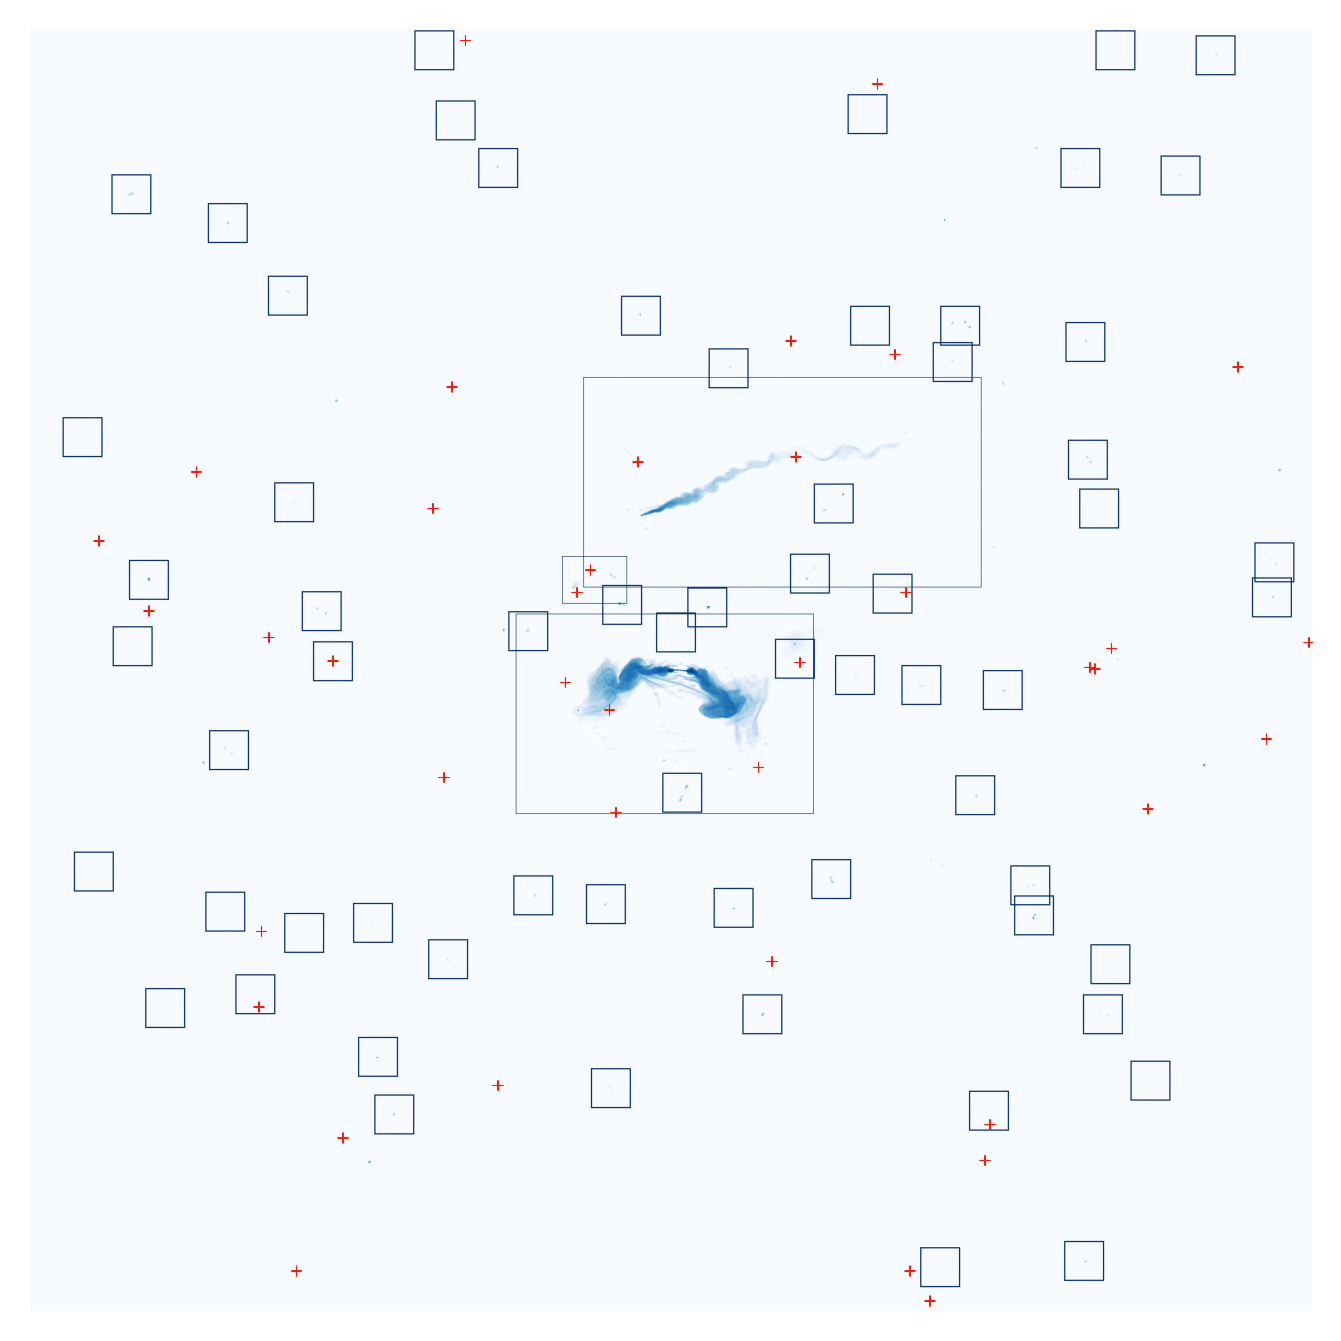

In [13]:
sky_box = np.zeros(sky_mf.grid.shape)
sky_box[markers_mf['oj_mrk']['x'], markers_mf['oj_mrk']['y']] = max_mf

print('plotting ...')
plot_arrays(
    array = (sky_box + samples_mf.mean(sky_mf.ref_freq_model) * CONV_FACTOR).clip(None, max_mf), 
    marker = markers_mf['ps_mrk'],
    **plot_dict,
)

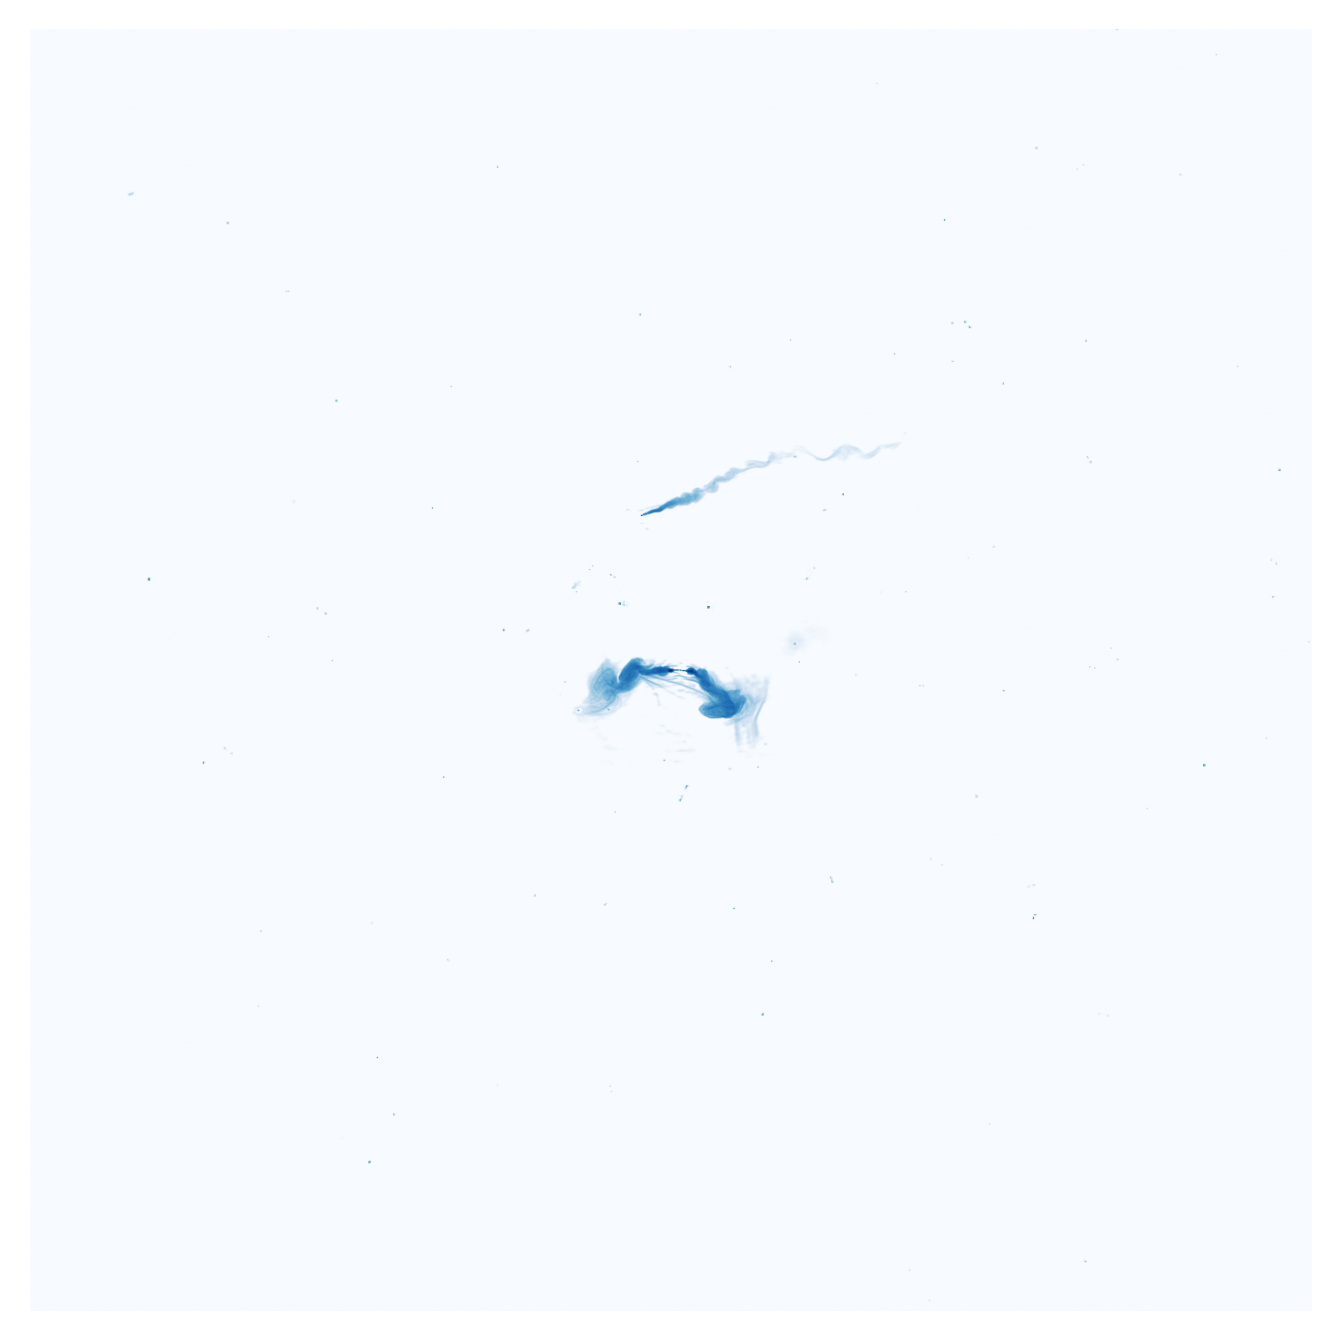

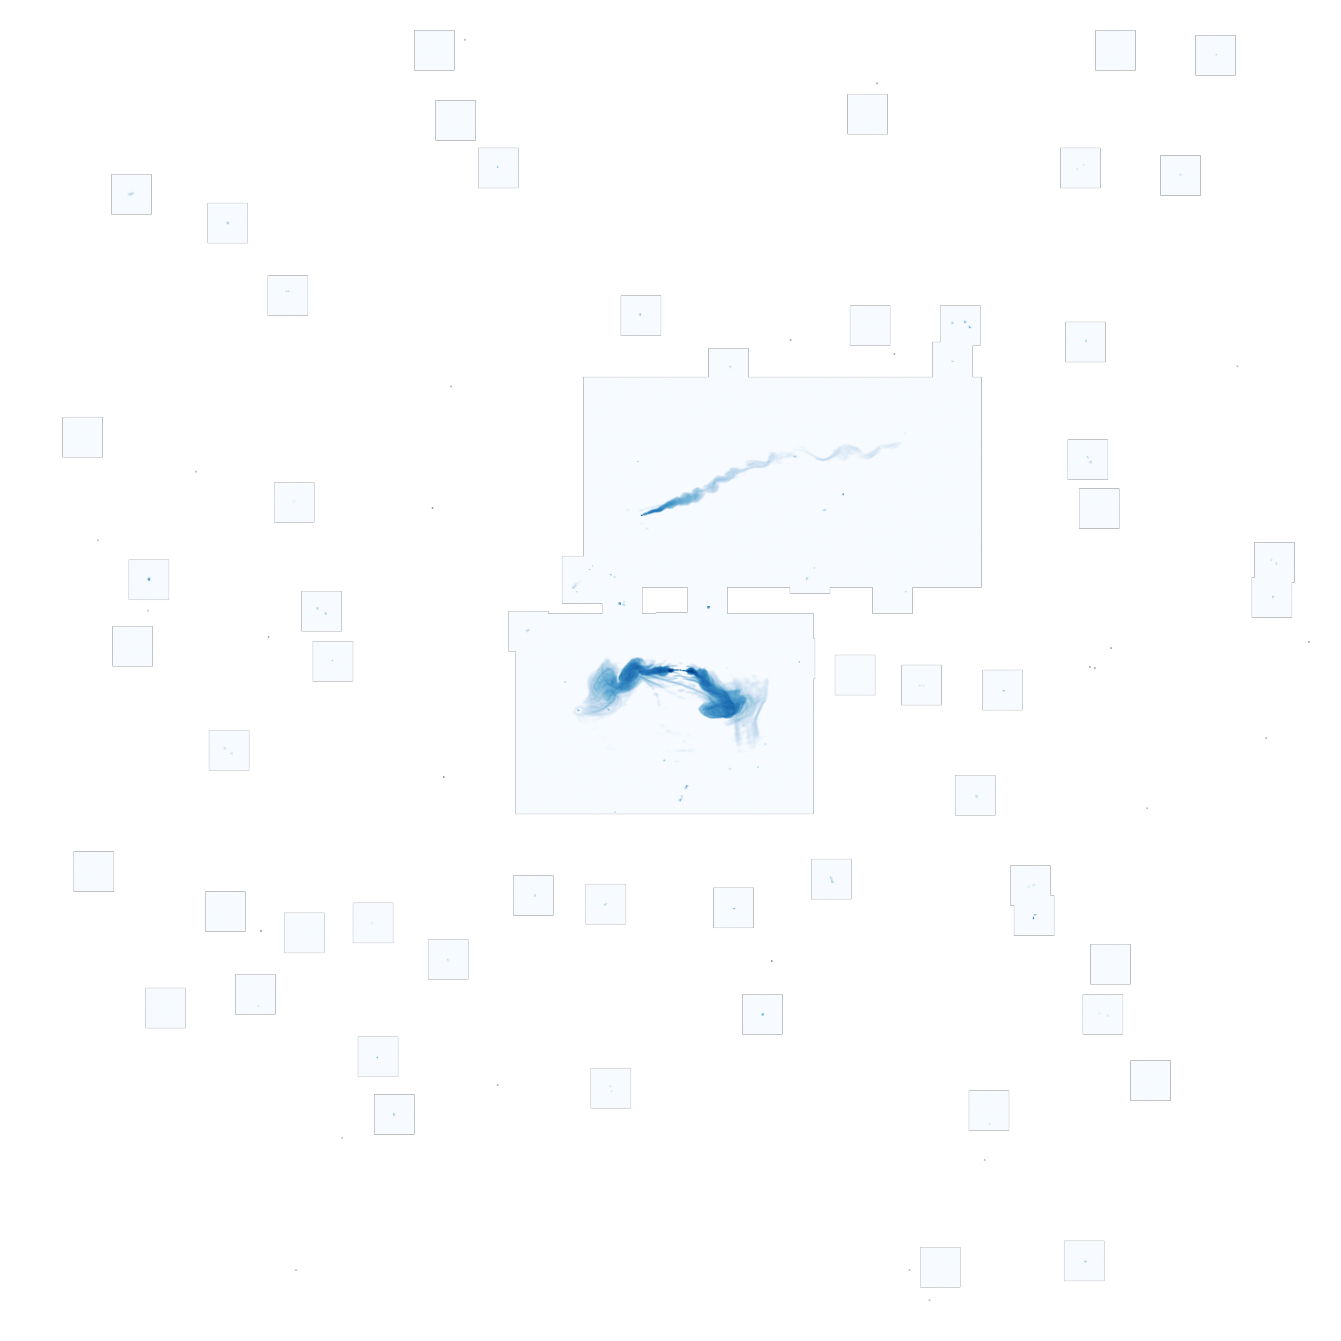

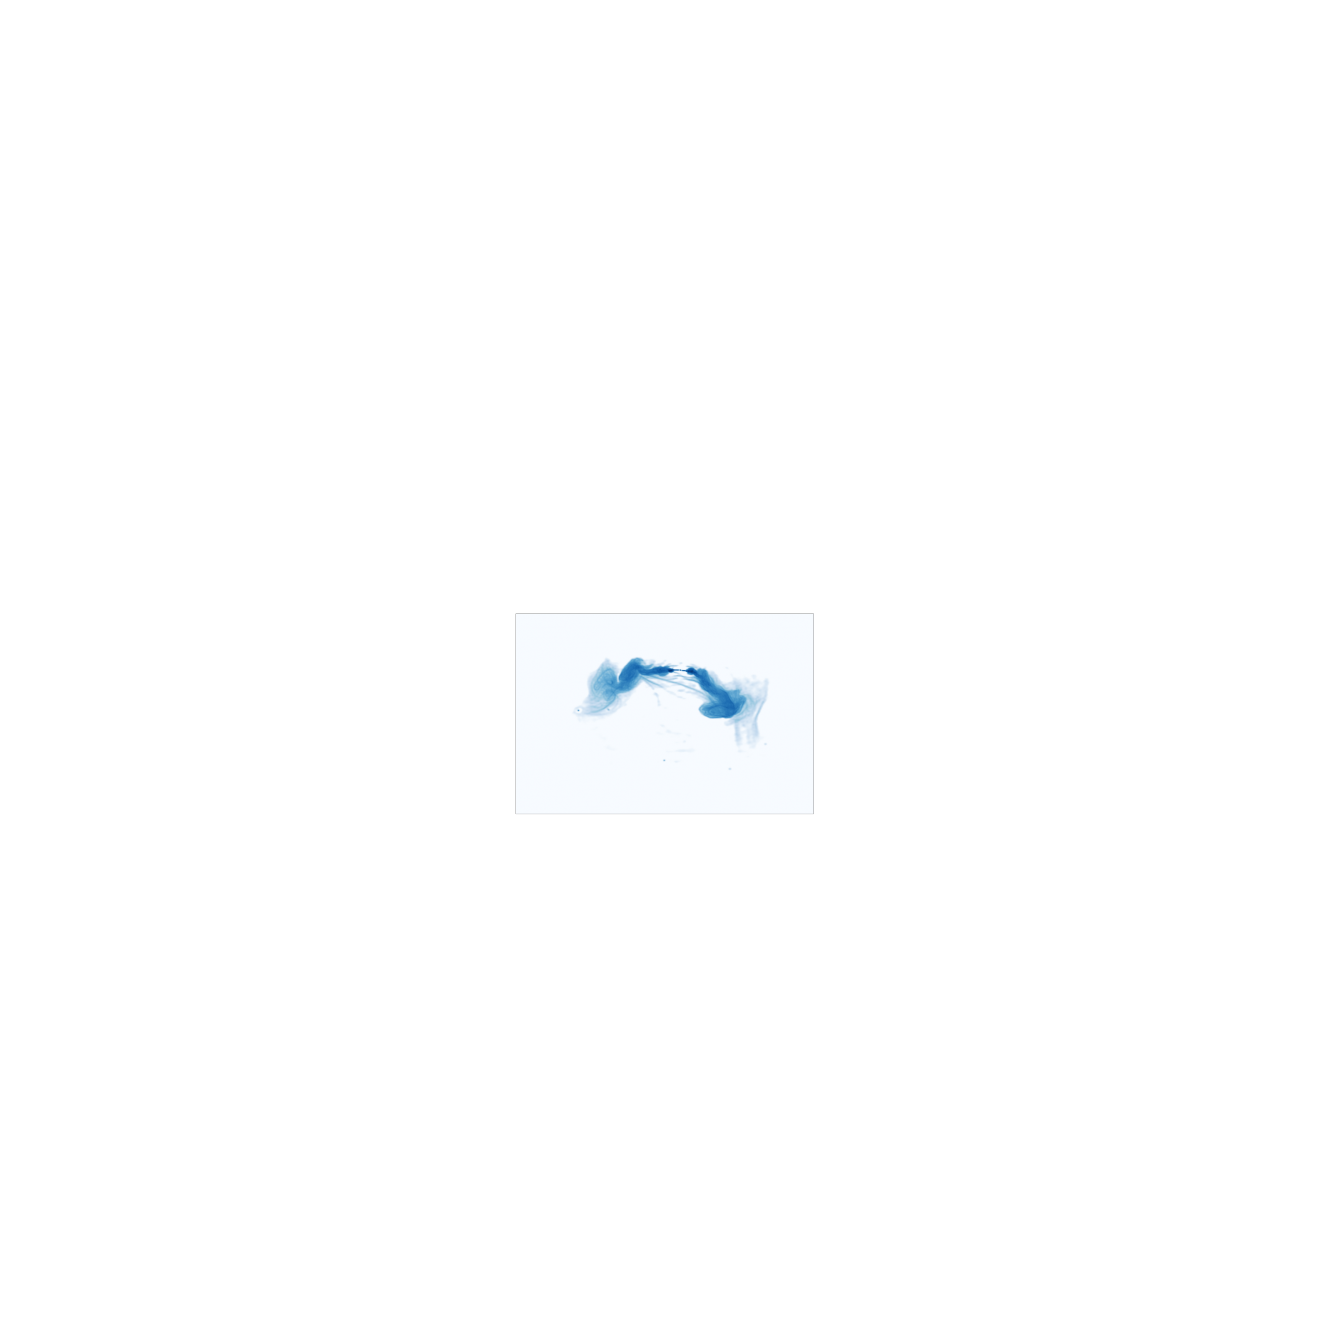

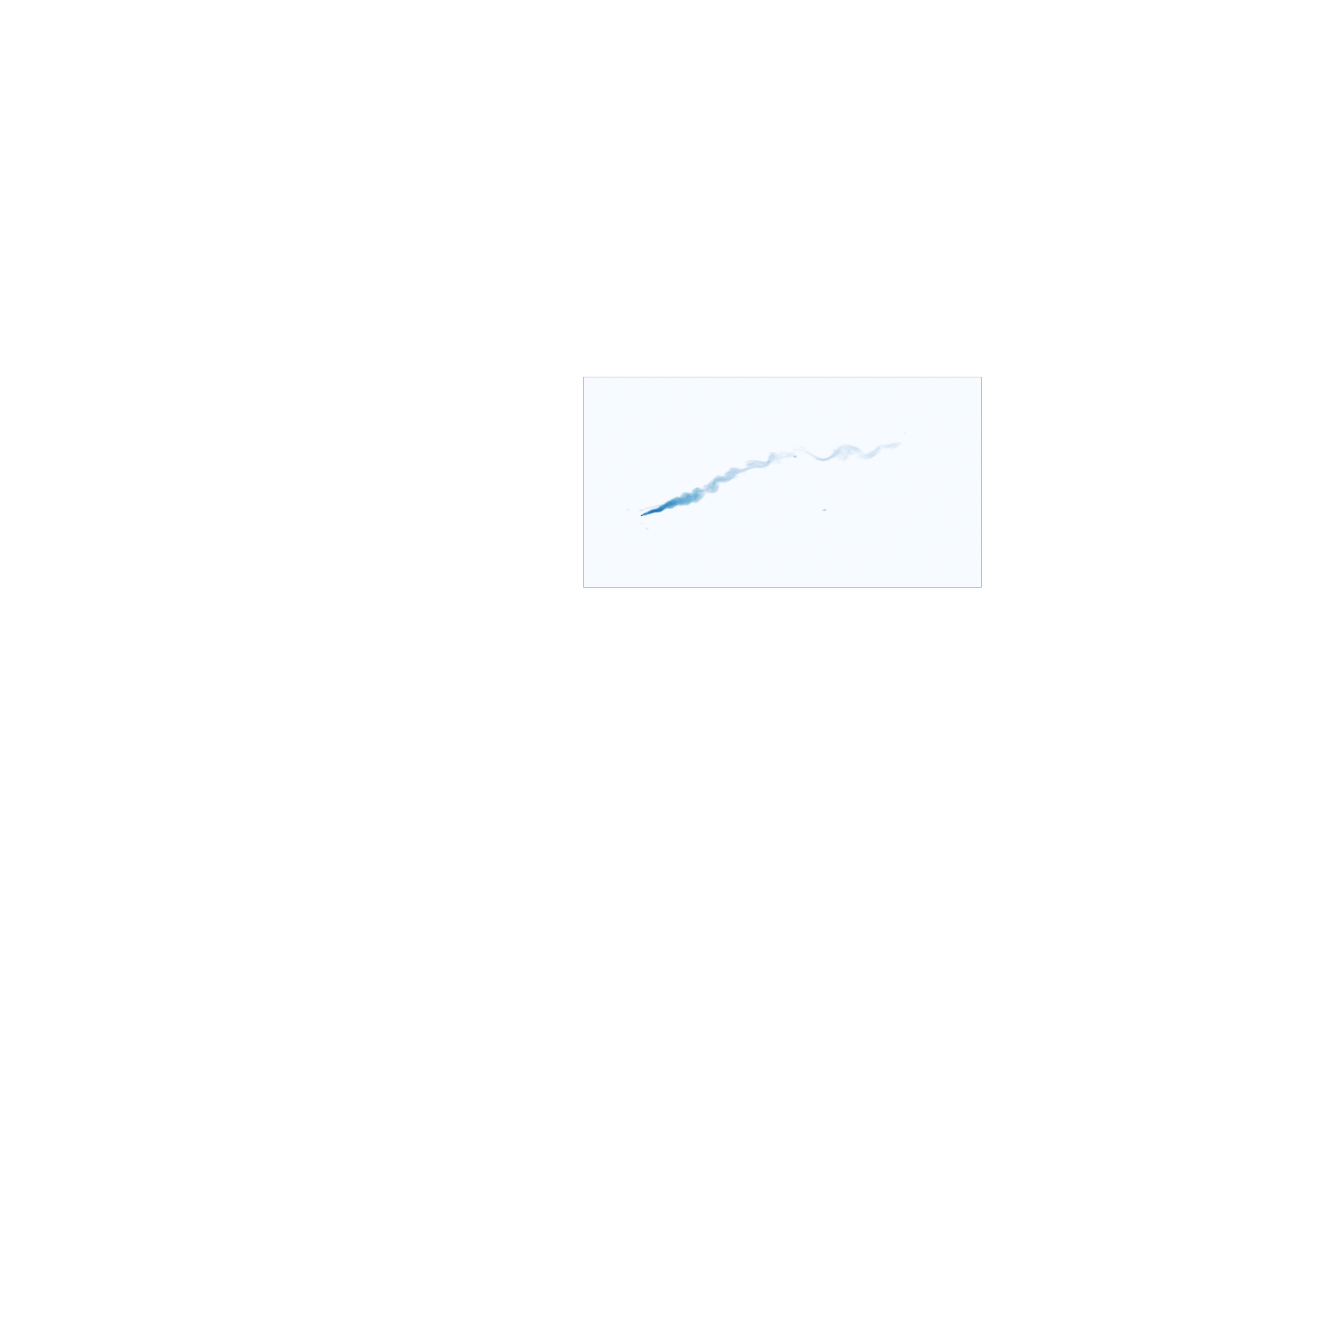

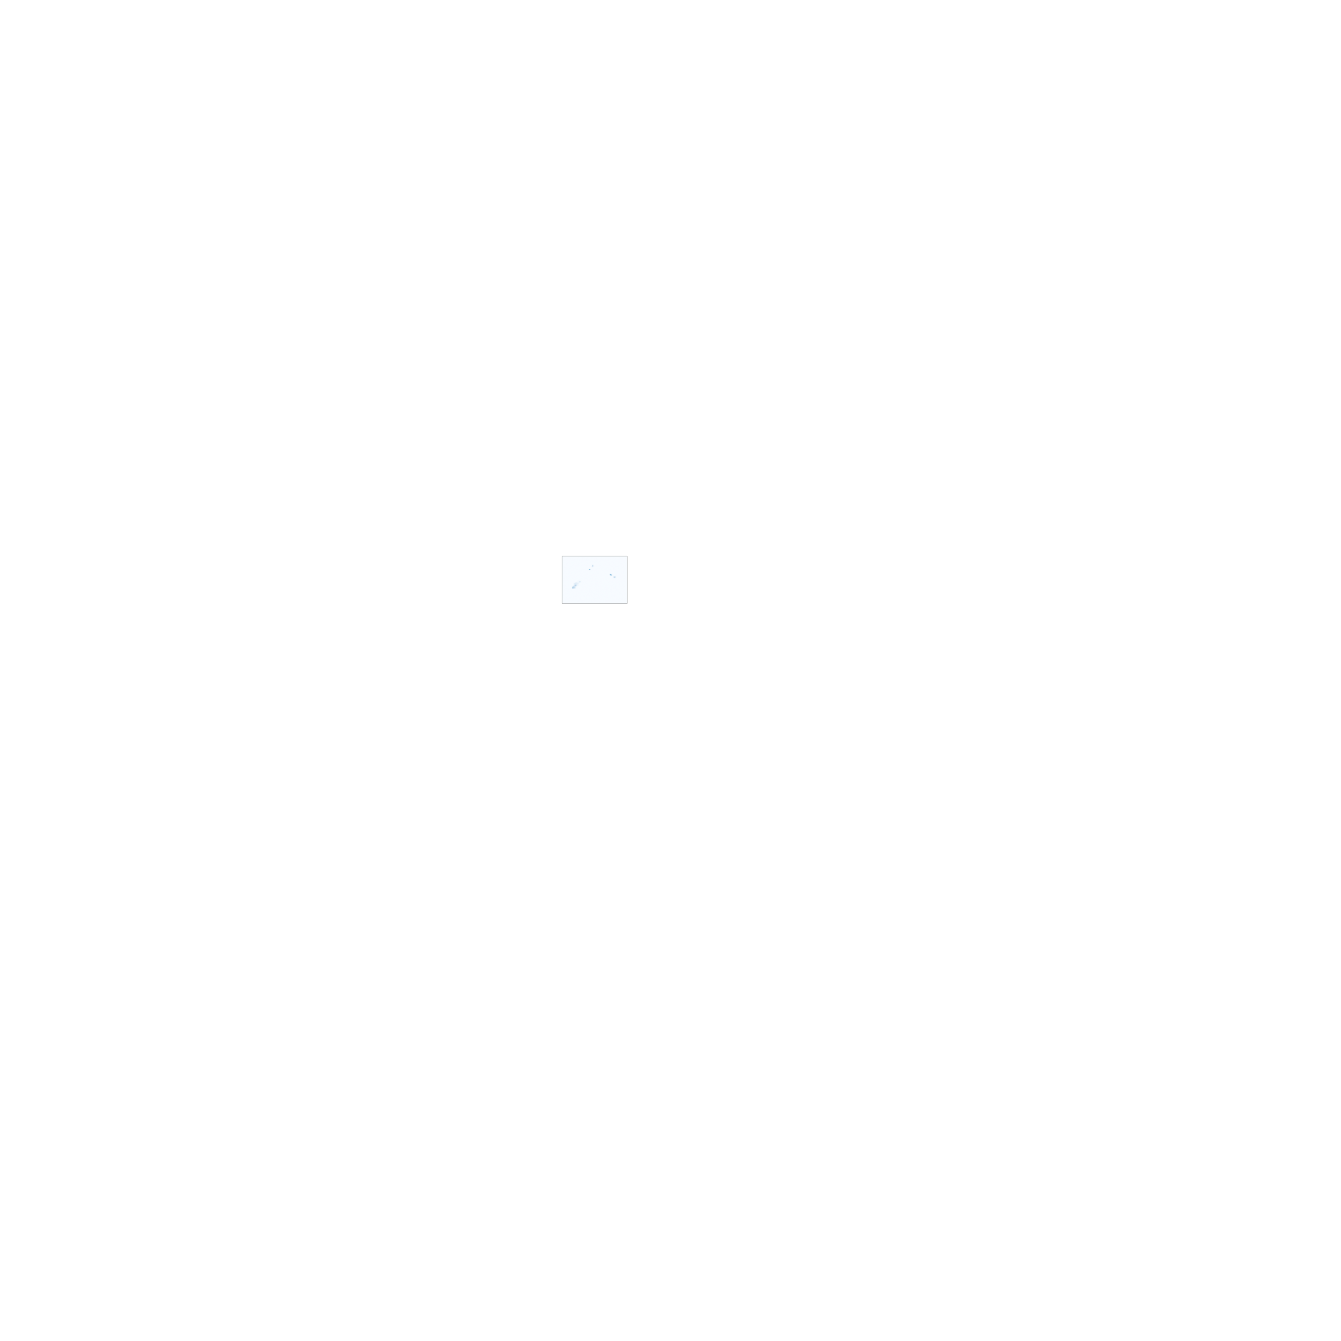

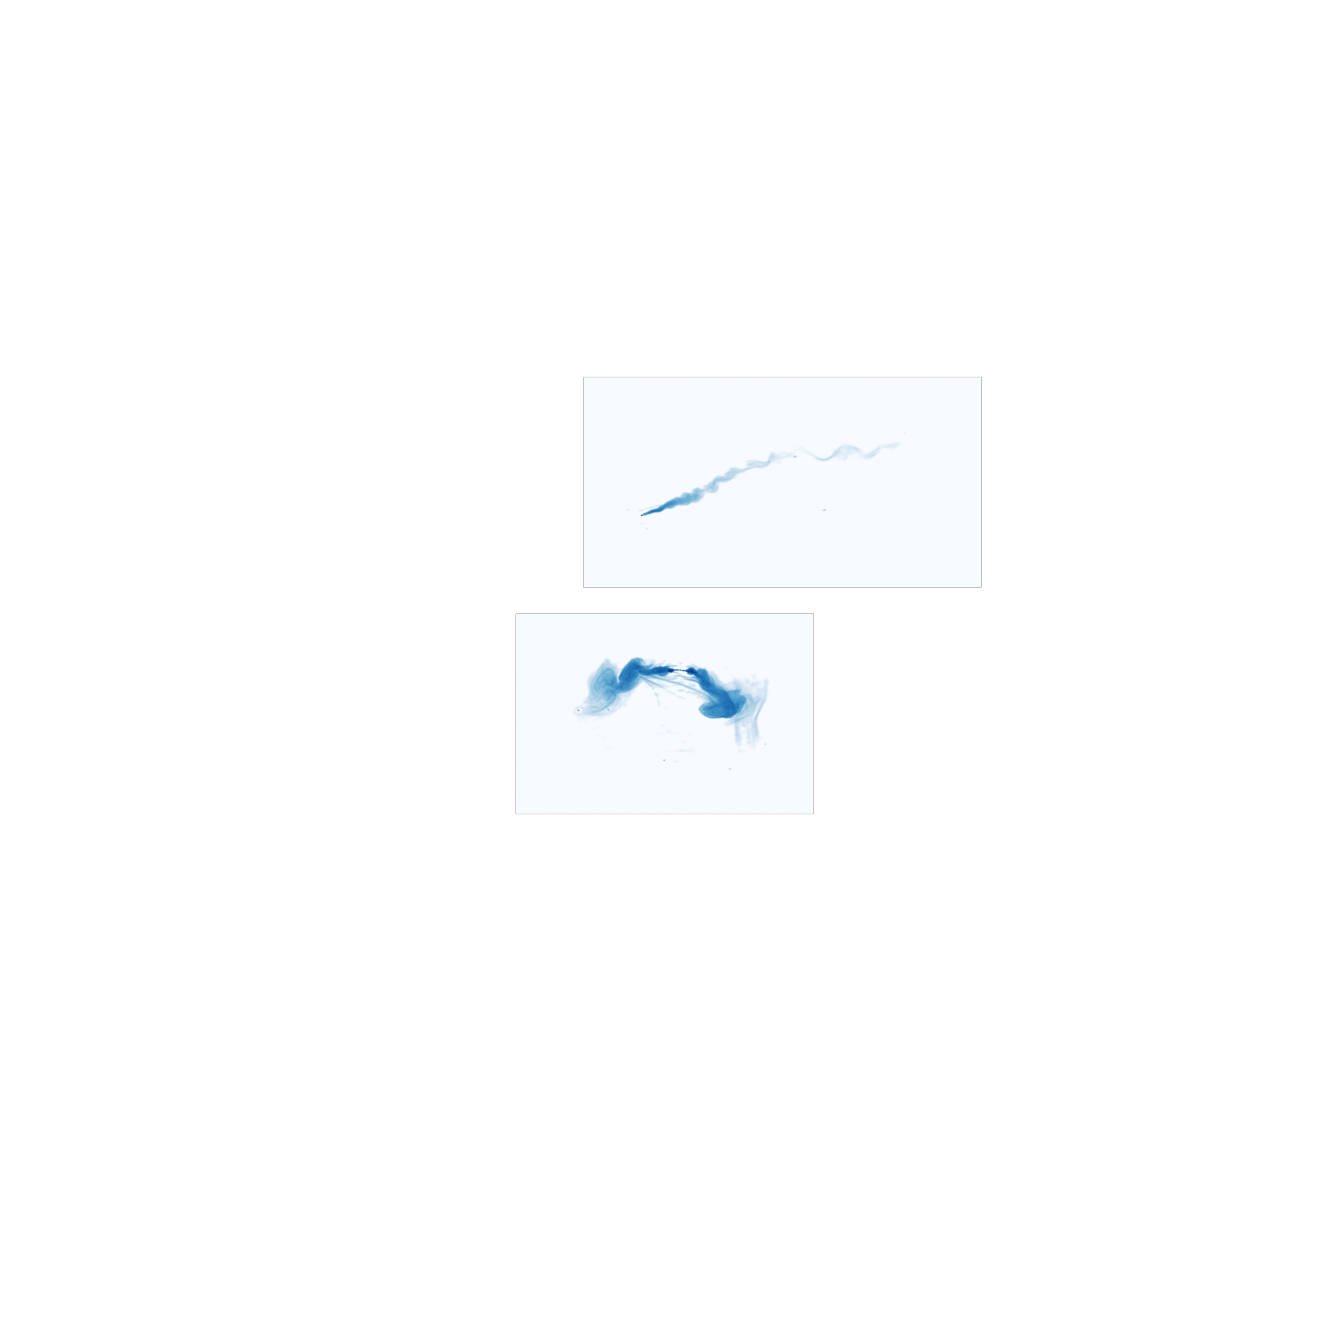

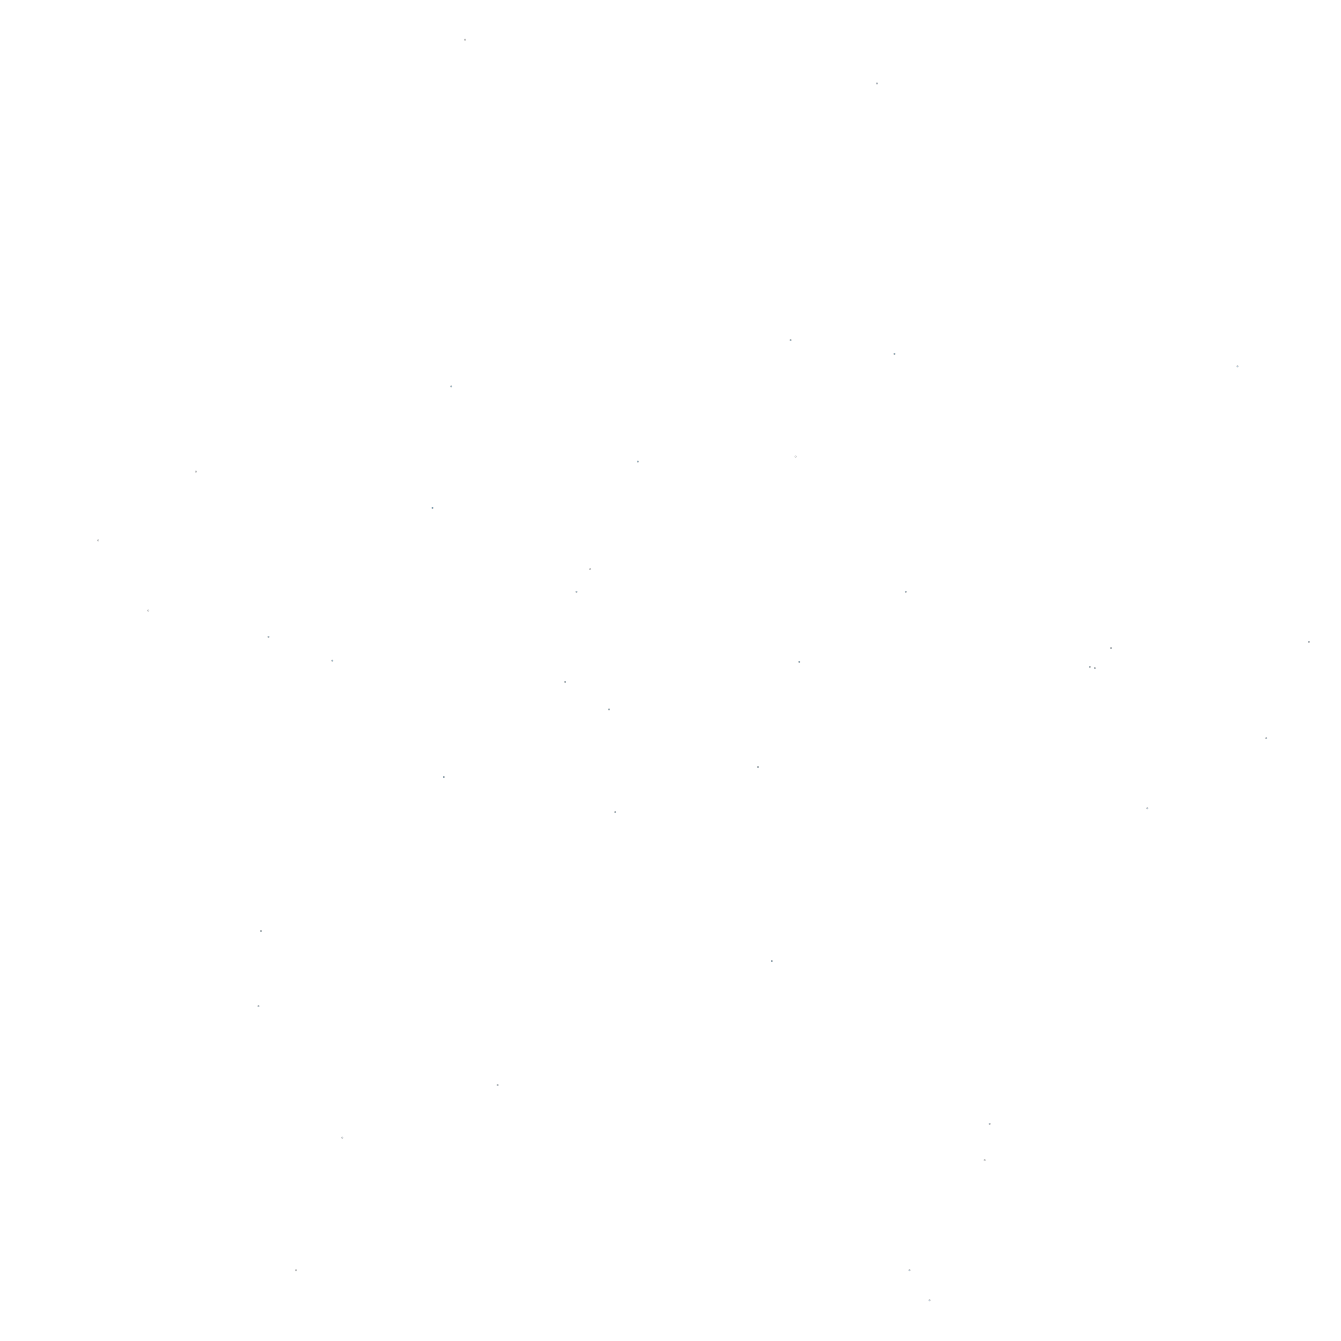

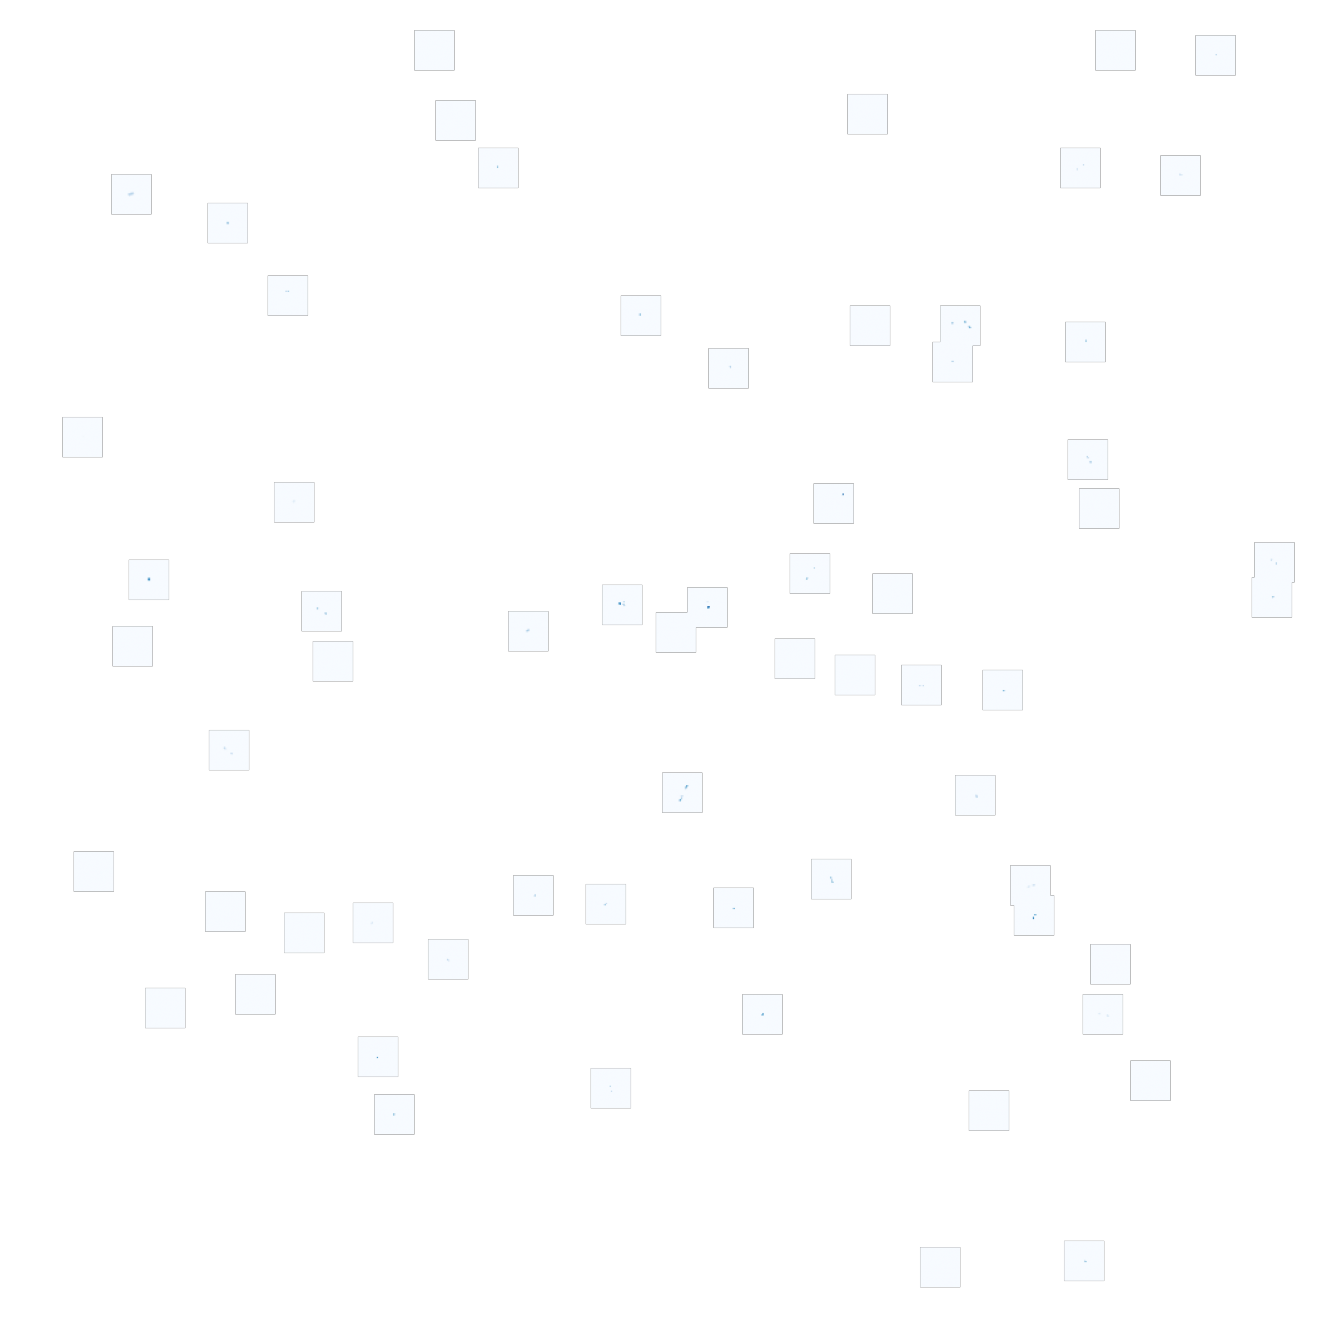

In [14]:
sky_oj12 = sky_mf.copy()
sky_oj12.models = sky_oj12.models[2:4]


comps = [
    sky_mf.ref_freq_model,
    sky_mf.points_and_objects.ref_freq_model,
    sky_mf.objects[0].ref_freq_model,
    sky_mf.objects[1].ref_freq_model,
    sky_mf.objects[2].ref_freq_model,
    sky_oj12.ref_freq_model,
    sky_mf.points[0].ref_freq_model,
    sky_mf.tiles[0].ref_freq_model,
]

for i,c in enumerate(comps):
    c.set_out_grid(sky_mf.grid)
    if i in [2,3,4]:
        c_ref = np.mean(tuple(c(s, map=True) for s in samples_mf), axis=0) * CONV_FACTOR
    else:
        c_ref = samples_mf.mean(c) * CONV_FACTOR
    # c_ref = np.where(c_ref == 0, c_ref[c_ref > 0].min(), c_ref)
    plot_arrays(
        array = c_ref, 
        **plot_dict,
    )